# D2C Customer Churn Intelligence & Retention Project

# Part 2: RFM Segmentation & Retention Strategy

## Objective

The objective of this analysis is to build RFM-based customer segments, enrich them using behavioural signals, and recommend targeted retention strategies for different customer groups.

Prepared by - Sakchhi Priya

# 1. Import Libraries

In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

pd.set_option('display.max_columns', None)

# 2. Load Datasets

In [56]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
tickets = pd.read_csv("support_tickets.csv")
web = pd.read_csv("web_events_snapshot.csv")
campaigns = pd.read_csv("intervention_history.csv")
churn = pd.read_csv("churn_labels.csv")

# 3. Create RFM Features

## Purpose

This section creates Recency, Frequency, and Monetary features using customer order history.

In [57]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

snapshot_date = orders["order_date"].max() + pd.Timedelta(days=1)

rfm = orders.groupby("customer_id").agg(
    Recency=("order_date",
             lambda x: (snapshot_date - x.max()).days),

    Frequency=("order_id", "count"),

    Monetary=("gross_amount", "sum")
).reset_index()

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,CUST00001,168,6,2955.57
1,CUST00002,35,3,1713.10
2,CUST00003,232,1,649.98
3,CUST00004,192,1,1604.04
4,CUST00005,11,6,3910.43


### Observation

The RFM dataset has been successfully created at the customer level.

Each customer now has:

- Recency: Number of days since the most recent purchase.
- Frequency: Total number of orders placed.
- Monetary: Total amount spent across all orders.

The generated RFM table provides a consolidated customer-level view of purchasing behaviour.

### Business Interpretation

Customers who purchased recently, order frequently, and spend more generally contribute higher business value.

Customers with large recency values may indicate declining engagement and potential retention risk.

### Recommendation

The company should use RFM metrics as the foundation for customer segmentation and retention planning.

Special attention should be given to customers with high spending but increasing recency, as they represent valuable customers who may be drifting away from the business.

# 4. RFM Score Creation

## Purpose

This section assigns RFM scores to customers based on their Recency, Frequency, and Monetary values.

These scores help identify highly valuable customers, loyal customers, and customers at risk of churn.

In [58]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,CUST00001,168,6,2955.57,2,4,3,243
1,CUST00002,35,3,1713.10,4,2,2,422
2,CUST00003,232,1,649.98,1,1,1,111
3,CUST00004,192,1,1604.04,2,1,2,212
4,CUST00005,11,6,3910.43,5,4,4,544


### Observation

RFM scores have been assigned to all customers based on purchasing behaviour.

Customers with higher scores represent stronger engagement and higher business value, while lower scores indicate customers who may require retention attention.

### Business Interpretation

RFM scoring provides a structured approach to ranking customers according to their relationship with the business.

### Recommendation

The company should use RFM scores as the foundation for customer segmentation and retention planning.

# 5. RFM Distribution Analysis

## Purpose

This section examines the distribution of Recency, Frequency, and Monetary metrics across customers.

The analysis helps identify customer concentration, spending patterns, and engagement behaviour.

In [59]:
rfm.describe()

,Recency,Frequency,Monetary
count,2400.000000,2400.000000,2400.000000
mean,106.552083,4.170417,3102.366721
std,103.035447,2.626960,2318.314239
min,1.000000,1.000000,149.000000
25%,23.000000,2.000000,1371.697500
50%,56.000000,4.000000,2621.735000
75%,180.250000,6.000000,4253.452500
max,623.000000,17.000000,27920.050000


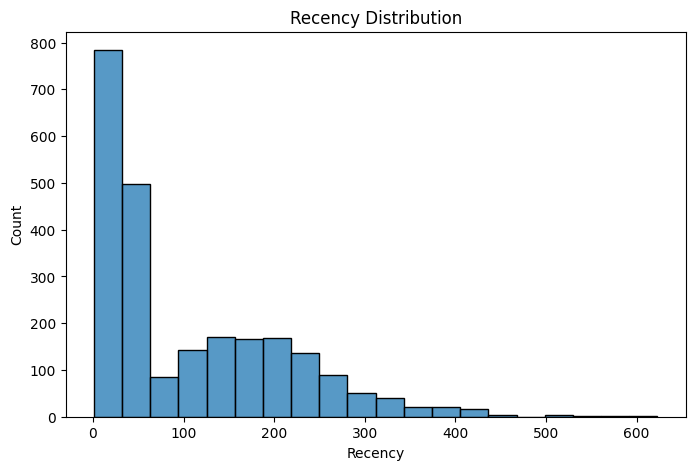

In [60]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["Recency"],
    bins=20
)

plt.title("Recency Distribution")

plt.show()

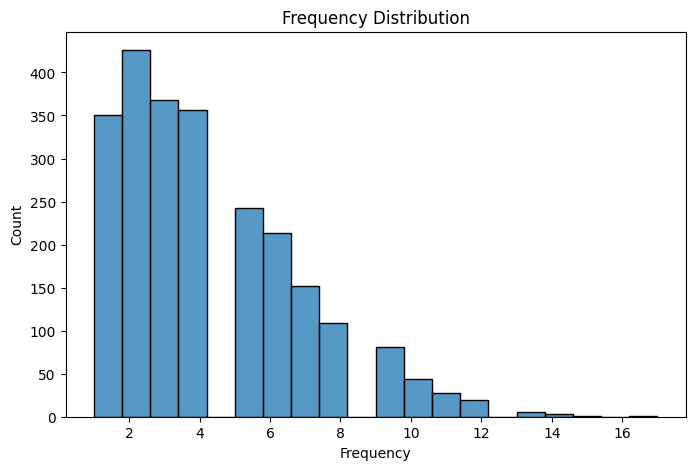

In [61]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["Frequency"],
    bins=20
)

plt.title("Frequency Distribution")

plt.show()

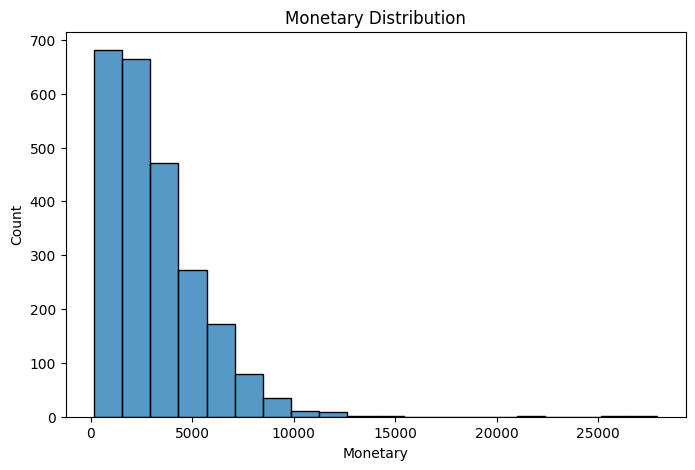

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["Monetary"],
    bins=20
)

plt.title("Monetary Distribution")

plt.show()

### Observation

The Recency distribution indicates a mix of active and inactive customers.

The Frequency distribution shows that some customers purchase significantly more often than others.

The Monetary distribution suggests that a smaller segment of customers contributes a large share of total revenue.

### Business Interpretation

Customer value is unevenly distributed across the customer base, making segmentation important for efficient resource allocation.

### Recommendation

Retention efforts should focus on customers with high spending and high purchase frequency, while re-engagement campaigns should target customers with increasing recency values.

# 6. Additional Behavioural Signals

## Purpose

RFM metrics alone may not fully explain customer behaviour.

This section enriches customer profiles using support interactions, return behaviour, loyalty participation, and digital engagement signals.

In [63]:
support_features = tickets.groupby(
    "customer_id"
).agg(
    ticket_count=("ticket_id","count"),
    avg_resolution_hours=("resolution_hours","mean"),
    avg_sentiment=("sentiment_score","mean"),
    reopened_tickets=("reopened","sum")
).reset_index()

support_features.head()

,customer_id,ticket_count,avg_resolution_hours,avg_sentiment,reopened_tickets
0,CUST00001,2,4.35,0.14,0
1,CUST00002,1,1.00,0.00,0
2,CUST00005,1,37.70,-1.00,0
3,CUST00006,2,17.60,-0.68,1
4,CUST00008,1,6.00,0.08,0


In [64]:
return_features = orders.groupby(
    "customer_id"
).agg(
    return_rate=("returned","mean"),
    avg_discount=("discount_pct","mean")
).reset_index()

return_features.head()

,customer_id,return_rate,avg_discount
0,CUST00001,0.166667,0.363333
1,CUST00002,0.000000,0.190000
2,CUST00003,0.000000,0.470000
3,CUST00004,0.000000,0.160000
4,CUST00005,0.000000,0.388333


In [65]:
rfm = rfm.merge(
    support_features,
    on="customer_id",
    how="left"
)

rfm = rfm.merge(
    return_features,
    on="customer_id",
    how="left"
)

rfm = rfm.merge(
    web,
    on="customer_id",
    how="left"
)

rfm = rfm.merge(
    customers[[
        "customer_id",
        "loyalty_tier"
    ]],
    on="customer_id",
    how="left"
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,ticket_count,avg_resolution_hours,avg_sentiment,reopened_tickets,return_rate,avg_discount,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,loyalty_tier
0,CUST00001,168,6,2955.57,2,4,3,243,2.0,4.35,0.14,0.0,0.166667,0.363333,2025-09-30,1,4,0,0,0,2,0,20,Silver
1,CUST00002,35,3,1713.10,4,2,2,422,1.0,1.00,0.00,0.0,0.000000,0.190000,2025-09-30,8,31,4,2,3,0,0,0,Silver
2,CUST00003,232,1,649.98,1,1,1,111,NaN,NaN,NaN,NaN,0.000000,0.470000,2025-09-30,1,3,0,0,0,0,0,26,NaN
3,CUST00004,192,1,1604.04,2,1,2,212,NaN,NaN,NaN,NaN,0.000000,0.160000,2025-09-30,1,6,0,0,0,0,0,14,NaN
4,CUST00005,11,6,3910.43,5,4,4,544,1.0,37.70,-1.00,0.0,0.000000,0.388333,2025-09-30,18,95,4,1,1,3,1,9,Gold


### Observation

Customer profiles have been enriched using support behaviour, return behaviour, web engagement, and loyalty information.

These additional signals provide a broader view of customer satisfaction and engagement beyond purchasing activity alone.

### Business Interpretation

Customers with high purchase value may still be at risk if they show poor engagement, high return rates, or frequent support issues.

### Recommendation

Retention decisions should incorporate both transactional behaviour and behavioural indicators to improve targeting accuracy.

# 7. Customer Segmentation Logic

## Purpose

This section creates actionable customer segments by combining RFM metrics with behavioural and engagement signals.

In [66]:
rfm["segment_name"] = "Regular Customers"

rfm.loc[
    (rfm["R_Score"] >= 4) &
    (rfm["F_Score"] >= 4) &
    (rfm["M_Score"] >= 4),
    "segment_name"
] = "Champions"

rfm.loc[
    (rfm["Frequency"] >= rfm["Frequency"].median()) &
    (rfm["Recency"] <= rfm["Recency"].median()),
    "segment_name"
] = "Loyal Customers"

rfm.loc[
    (rfm["Recency"] > rfm["Recency"].quantile(0.75)),
    "segment_name"
] = "Dormant Customers"

rfm.loc[
    (rfm["avg_discount"] >
     rfm["avg_discount"].median()),
    "segment_name"
] = "Discount Sensitive"

rfm.loc[
    (rfm["Monetary"] >
     rfm["Monetary"].quantile(0.75)) &
    (
        (rfm["ticket_count"] >
         rfm["ticket_count"].median())
        |
        (rfm["return_rate"] > 0.20)
    ),
    "segment_name"
] = "High Value But Unhappy"

In [67]:
rfm["segment_name"].value_counts()

,count
segment_name,
Discount Sensitive,1071
Regular Customers,412
Loyal Customers,348
High Value But Unhappy,276
Dormant Customers,268
Champions,25


### Observation

Multiple customer segments have been created using both RFM and behavioural signals.

The segmentation identifies high-value customers, loyal customers, dormant customers, discount-sensitive customers, and customers showing signs of dissatisfaction.

### Business Interpretation

Different customer groups require different retention strategies.

A single retention campaign is unlikely to be equally effective across all segments.

### Recommendation

Future retention efforts should be personalized according to customer segment characteristics and business value.

# 8. Segment Analysis

## Purpose

This section analyzes the distribution of customers across different segments.

The objective is to understand the size, value, and characteristics of each segment before designing retention strategies.

In [68]:
rfm["segment_name"].value_counts()

,count
segment_name,
Discount Sensitive,1071
Regular Customers,412
Loyal Customers,348
High Value But Unhappy,276
Dormant Customers,268
Champions,25


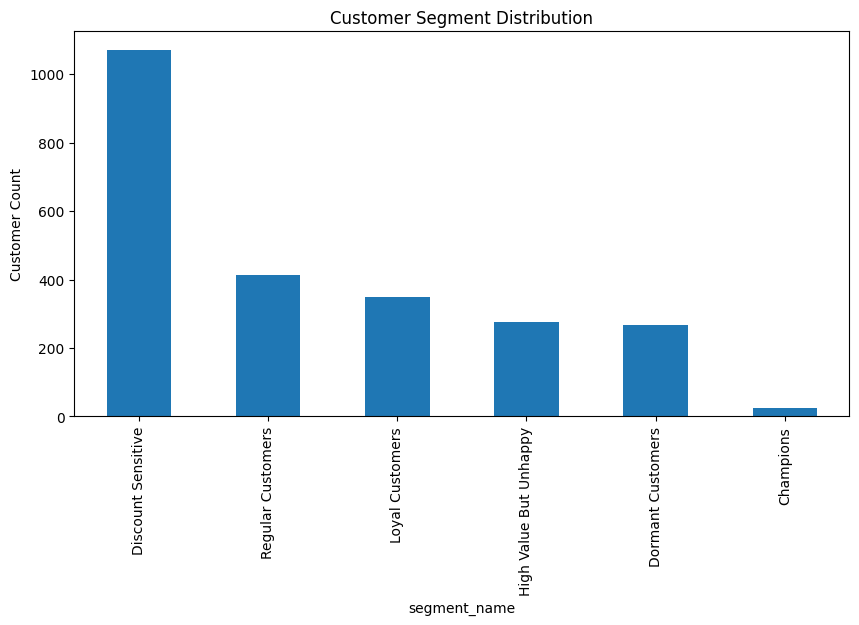

In [69]:
plt.figure(figsize=(10,5))

rfm["segment_name"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segment Distribution")

plt.ylabel("Customer Count")

plt.show()

In [70]:
segment_summary = rfm.groupby(
    "segment_name"
).agg(
    Customers=("customer_id","count"),
    Avg_Recency=("Recency","mean"),
    Avg_Frequency=("Frequency","mean"),
    Avg_Monetary=("Monetary","mean")
).reset_index()

segment_summary

,segment_name,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
0,Champions,25,105.840000,6.240000,4768.195200
1,Discount Sensitive,1071,117.825397,3.642390,2452.068730
2,Dormant Customers,268,253.731343,2.798507,2216.300373
3,High Value But Unhappy,276,70.253623,8.108696,6492.333080
4,Loyal Customers,348,25.902299,5.747126,4481.469713
5,Regular Customers,412,73.990291,2.339806,1832.295510


### Observation

Customer segments show meaningful differences in purchasing behaviour and business value.

Some segments contain highly engaged and valuable customers, while others represent customers with declining activity or satisfaction concerns.

### Business Interpretation

Segment-level analysis allows the business to allocate retention resources more effectively and design targeted interventions.

### Recommendation

Retention strategies should be customized according to segment characteristics rather than applying a single campaign to all customers.

# 9. Retention Strategy

## Purpose

This section defines recommended retention actions for each customer segment based on behavioural characteristics and business value.

In [71]:
retention_strategy = pd.DataFrame({

    "Segment":[
        "Champions",
        "Loyal Customers",
        "Dormant Customers",
        "Discount Sensitive",
        "High Value But Unhappy",
        "Regular Customers"
    ],

    "Recommended_Action":[
        "VIP rewards and exclusive offers",
        "Loyalty program upgrades",
        "Reactivation campaigns",
        "Targeted discount offers",
        "Dedicated support outreach",
        "Personalized engagement campaigns"
    ]

})

retention_strategy

,Segment,Recommended_Action
0,Champions,VIP rewards and exclusive offers
1,Loyal Customers,Loyalty program upgrades
2,Dormant Customers,Reactivation campaigns
3,Discount Sensitive,Targeted discount offers
4,High Value But Unhappy,Dedicated support outreach
5,Regular Customers,Personalized engagement campaigns


### Observation

Different customer segments exhibit different levels of engagement, value, and retention risk.

### Business Interpretation

A personalized retention strategy is likely to be more effective than a generic campaign applied to all customers.

### Recommendation

Customer retention investments should be aligned with both customer value and churn risk.

# 10. Campaign Budget Prioritization

## Purpose

Assume a limited retention budget is available.

The company must prioritize customer groups that offer the highest potential business impact.

### Budget Assumption

Assume a retention budget of $10,000.

### Priority Order

1. High Value But Unhappy Customers
2. Dormant Customers
3. Loyal Customers
4. Discount Sensitive Customers
5. Regular Customers
6. Champions

### Reasoning

High Value But Unhappy customers contribute significant revenue but show dissatisfaction signals. Retaining even a small number of these customers may generate substantial business value.

Dormant customers represent recoverable revenue opportunities.

Champions already demonstrate strong engagement and therefore require lower retention investment.

### Recommendation

The majority of retention spending should focus on customers who combine high business value with elevated churn risk.

# 11. Manual Review Cases

## Purpose

Some customers cannot be classified confidently using automated rules alone.

This section identifies customers requiring manual review before retention actions are finalized.

In [72]:
manual_review = rfm[
    (
        (rfm["Monetary"] > rfm["Monetary"].quantile(0.75))
        &
        (rfm["ticket_count"] > rfm["ticket_count"].median())
    )
    |
    (
        (rfm["Frequency"] > rfm["Frequency"].median())
        &
        (rfm["Recency"] > rfm["Recency"].median())
    )
].head(10)

manual_review

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,ticket_count,avg_resolution_hours,avg_sentiment,reopened_tickets,return_rate,avg_discount,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,loyalty_tier,segment_name
0,CUST00001,168,6,2955.57,2,4,3,243,2.0,4.350000,0.140000,0.0,0.166667,0.363333,2025-09-30,1,4,0,0,0,2,0,20,Silver,Discount Sensitive
13,CUST00014,1,13,9108.63,5,5,5,555,2.0,8.250000,-0.245000,0.0,0.000000,0.280769,2025-09-30,11,57,3,2,2,0,0,17,NaN,High Value But Unhappy
24,CUST00025,226,7,4868.86,1,5,5,155,3.0,18.000000,-0.226667,1.0,0.000000,0.311429,2025-09-30,11,54,2,3,1,6,1,29,NaN,High Value But Unhappy
41,CUST00042,46,10,7919.28,3,5,5,355,6.0,12.000000,-0.455000,2.0,0.200000,0.222000,2025-09-30,3,13,1,0,0,7,2,14,Silver,High Value But Unhappy
50,CUST00051,271,4,4444.30,1,3,4,134,2.0,42.200000,-0.385000,0.0,0.000000,0.352500,2025-09-30,6,32,2,1,1,8,2,35,NaN,High Value But Unhappy
52,CUST00053,10,6,5422.92,5,4,5,545,2.0,47.150000,-0.565000,1.0,0.000000,0.301667,2025-09-30,9,29,2,2,1,3,1,5,Silver,High Value But Unhappy
65,CUST00066,381,5,4598.95,1,4,4,144,1.0,23.900000,-1.000000,0.0,0.000000,0.292000,2025-09-30,11,35,2,2,1,5,1,60,NaN,Discount Sensitive
74,CUST00075,44,11,7714.72,3,5,5,355,4.0,27.125000,-0.352500,1.0,0.000000,0.317273,2025-09-30,10,43,2,1,1,0,0,13,NaN,High Value But Unhappy
80,CUST00081,41,9,5805.78,4,5,5,455,3.0,17.333333,-0.833333,1.0,0.222222,0.152222,2025-09-30,12,63,4,2,1,0,0,0,Silver,High Value But Unhappy
87,CUST00088,159,12,6774.50,2,5,5,255,1.0,17.100000,-0.880000,1.0,0.000000,0.365000,2025-09-30,9,29,2,1,1,1,0,18,Gold,Discount Sensitive


### Observation

The selected customers exhibit mixed behavioural patterns.

Some customers generate high revenue but show dissatisfaction signals, while others have historically strong purchasing behaviour but declining engagement.

### Business Interpretation

These customers require additional review because automated segmentation may not fully capture their retention potential.

### Recommendation

Customer success teams should review these customers individually before launching retention campaigns.

# 12. Export Segments Dataset

## Purpose

This section creates the final segmentation dataset required for business use and repository submission.

In [73]:
segments = rfm[[
    "customer_id",
    "segment_name",
    "Recency",
    "Frequency",
    "Monetary",
    "ticket_count",
    "return_rate",
    "sessions_30d",
    "campaign_clicks_30d",
    "loyalty_tier"
]]

segments.head()

,customer_id,segment_name,Recency,Frequency,Monetary,ticket_count,return_rate,sessions_30d,campaign_clicks_30d,loyalty_tier
0,CUST00001,Discount Sensitive,168,6,2955.57,2.0,0.166667,1,0,Silver
1,CUST00002,Regular Customers,35,3,1713.10,1.0,0.000000,8,0,Silver
2,CUST00003,Discount Sensitive,232,1,649.98,NaN,0.000000,1,0,NaN
3,CUST00004,Dormant Customers,192,1,1604.04,NaN,0.000000,1,0,NaN
4,CUST00005,Discount Sensitive,11,6,3910.43,1.0,0.000000,18,1,Gold


In [74]:
segments.to_csv(
    "segments.csv",
    index=False
)

print("segments.csv exported successfully")

segments.csv exported successfully


### Observation

The final segmentation dataset contains customer identifiers, assigned segments, RFM metrics, and behavioural signals.

### Business Interpretation

The exported dataset can be used directly by marketing, CRM, and customer success teams for targeted retention initiatives.

### Recommendation

This dataset should be refreshed periodically to ensure retention decisions reflect current customer behaviour.

# 13. Conclusion

This analysis developed customer segments using RFM metrics and additional behavioural signals.

Key findings include:

- Customer value is unevenly distributed across the customer base.
- High-value customers require proactive retention monitoring.
- Support interactions, return behaviour, and digital engagement provide valuable signals beyond transaction history.
- Different customer segments require different retention approaches.
- Budget allocation should prioritize customers who combine high business value with elevated churn risk.

Overall, the segmentation framework provides a practical foundation for targeted retention strategies and future predictive modeling initiatives.